In [1]:
print('go')

go


In [ ]:
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt

nta_values = [41,42,43,51,52,71,72,73,74]

raster20 = rioxarray.open_rasterio(r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\Annual_NLCD_LndChg_2000_CU_C1V1_8cf643cf-7a3e-4b8f-af1c-28643e3ed0eb.tiff")
raster24 = rioxarray.open_rasterio(r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\Annual_NLCD_LndCov_2024_CU_C1V1_8cf643cf-7a3e-4b8f-af1c-28643e3ed0eb.tiff")

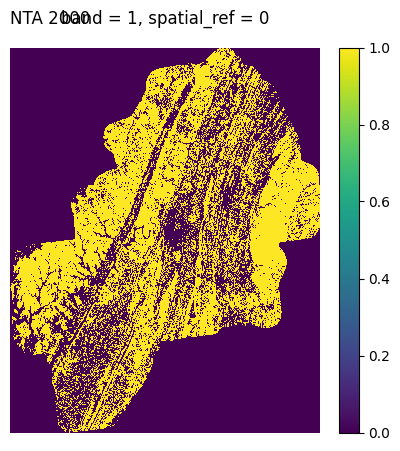

In [20]:
# filter
raster20_nta = raster20.isin( nta_values ).astype(int)

# Plot
fig,ax = plt.subplots(figsize=(5,5))
raster20_nta.plot(ax=ax)
ax.set_title("NTA 2000", loc='left')
ax.axis("off");

Error in callback <function _draw_all_if_interactive at 0x000002521D457920> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

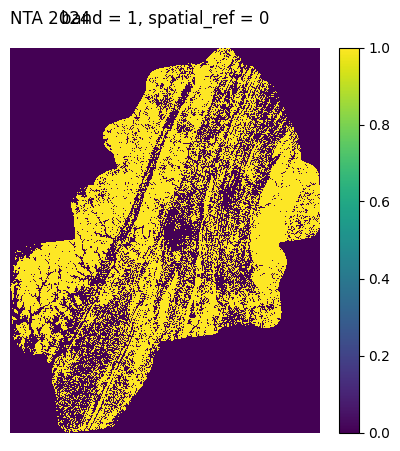

In [21]:
raster24_nta = raster24.isin( nta_values ).astype(int)

# Plot
fig,ax = plt.subplots(figsize=(5,5))
raster24_nta.plot(ax=ax)
ax.set_title("NTA 2024", loc='left')
ax.axis("off");

In [5]:
nta_change = raster24_nta - raster20_nta
nta_change

<xarray.DataArray (band: 1, y: 7009, x: 6584)> Size: 369MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 7009, 6584))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 56kB 1.486e+06 1.486e+06 ... 1.276e+06 1.276e+06
  * x            (x) float64 53kB 8.652e+05 8.652e+05 ... 1.063e+06 1.063e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MINIMUM:        11
    STATISTICS_VALID_PERCENT:  56.94
    scale_factor:              1.0
    add_offset:                0.0

The values are calculated by *2024 - 2000*  

|value|meaning|
|-|-|
|1| **gain** until 2024 |
|0| no change|
|-1| **loss** until 2024 |

#### Simple Summary
1 = gain  
-1 = loss  
0 = no change

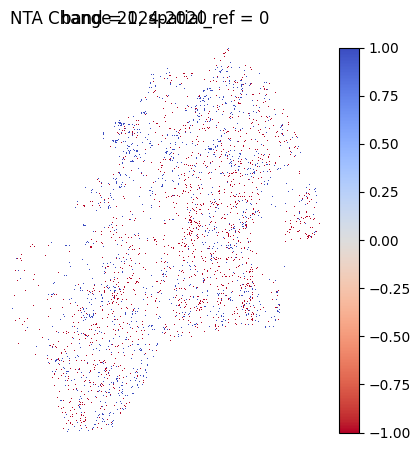

In [7]:
# Plot
fig,ax = plt.subplots(figsize=(5,5))
nta_change.where( nta_change != 0 ).plot(ax=ax, cmap='coolwarm_r')
ax.set_title("NTA Change 2024-2020", loc='left')
ax.axis("off");

In [8]:
nta_change.rio.write_nodata(0, inplace=True)
nta_change.rio.to_raster( r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\NTA_Change.tiff")

## Urban

In [23]:
# 21: Developped Open Space is Roads and Parking
dev_values = [21,22,23,24]


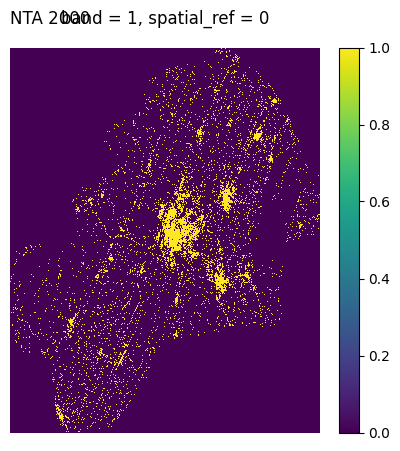

In [24]:
# filter
raster20_dev = raster20.isin( dev_values ).astype(int)

# Plot
fig,ax = plt.subplots(figsize=(5,5))
raster20_dev.plot(ax=ax)
ax.set_title("DEVELOPPED 2000", loc='left')
ax.axis("off");

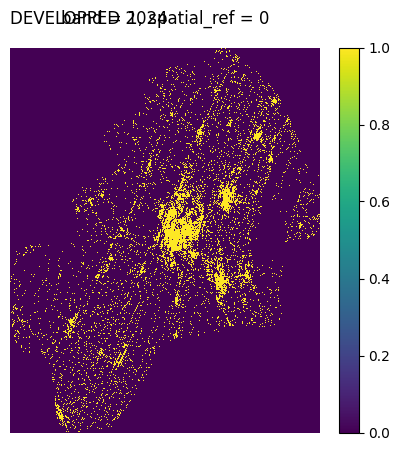

In [25]:
raster24_dev = raster24.isin( dev_values ).astype(int)

# Plot
fig,ax = plt.subplots(figsize=(5,5))
raster24_dev.plot(ax=ax)
ax.set_title("DEVELOPPED 2024", loc='left')
ax.axis("off");

In [26]:
dev_change = raster24_dev - raster20_dev
dev_change

<xarray.DataArray (band: 1, y: 7009, x: 6584)> Size: 369MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 7009, 6584))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 56kB 1.486e+06 1.486e+06 ... 1.276e+06 1.276e+06
  * x            (x) float64 53kB 8.652e+05 8.652e+05 ... 1.063e+06 1.063e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MINIMUM:        11
    STATISTICS_VALID_PERCENT:  56.94
    scale_factor:              1.0
    add_offset:                0.0

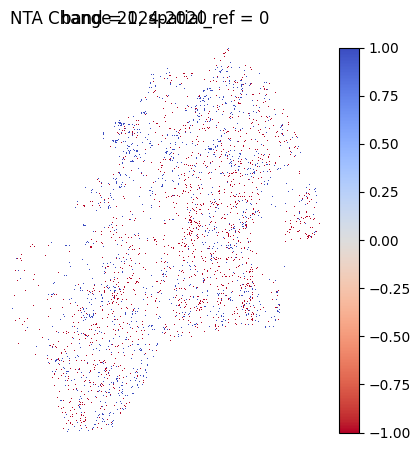

In [27]:
# Plot
fig,ax = plt.subplots(figsize=(5,5))
dev_change.where( dev_change != 0 ).plot(ax=ax, cmap='coolwarm_r')
ax.set_title("NTA Change 2024-2020", loc='left')
ax.axis("off");

In [28]:
dev_change.rio.write_nodata(0, inplace=True)
dev_change.rio.to_raster( r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\Dev_Change.tiff")

## Process Data

In [86]:
import geopandas as gpd
df = gpd.read_file(r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\landuse_Change_1miGrid.geojson")
df.head()

,id,NTA_-1,NTA_NODATA,NTA_1,Dev_-1,Dev_NODATA,Dev_1,geometry
0,1,0,2916,0,0,2916,0,"POLYGON ((-86.29488 36.03126, -86.27696 36.029..."
1,2,0,2862,0,0,2862,0,"POLYGON ((-86.29672 36.01697, -86.2788 36.0155..."
2,3,0,2916,0,0,2916,0,"POLYGON ((-86.29856 36.00267, -86.28064 36.001..."
3,4,0,2916,0,0,2916,0,"POLYGON ((-86.30039 35.98838, -86.28248 35.986..."
4,5,0,2862,0,0,2862,0,"POLYGON ((-86.30223 35.97408, -86.28431 35.972..."


In [87]:
cols = df.columns.str.replace( "_NODATA" , "-No Change" )
cols = cols. str.replace( "_-1" , "-Loss" )
cols = cols. str.replace( "_1" , "-Gain" )
cols = cols. str.replace( "Dev" , "Developped" )

df.columns = cols
df.head()

,id,NTA-Loss,NTA-No Change,NTA-Gain,Developped-Loss,Developped-No Change,Developped-Gain,geometry
0,1,0,2916,0,0,2916,0,"POLYGON ((-86.29488 36.03126, -86.27696 36.029..."
1,2,0,2862,0,0,2862,0,"POLYGON ((-86.29672 36.01697, -86.2788 36.0155..."
2,3,0,2916,0,0,2916,0,"POLYGON ((-86.29856 36.00267, -86.28064 36.001..."
3,4,0,2916,0,0,2916,0,"POLYGON ((-86.30039 35.98838, -86.28248 35.986..."
4,5,0,2862,0,0,2862,0,"POLYGON ((-86.30223 35.97408, -86.28431 35.972..."


In [88]:
df['pixel-count'] = df['NTA-Loss'] + df['NTA-Gain'] + df['NTA-No Change']

df.head()

,id,NTA-Loss,NTA-No Change,NTA-Gain,Developped-Loss,Developped-No Change,Developped-Gain,geometry,pixel-count
0,1,0,2916,0,0,2916,0,"POLYGON ((-86.29488 36.03126, -86.27696 36.029...",2916
1,2,0,2862,0,0,2862,0,"POLYGON ((-86.29672 36.01697, -86.2788 36.0155...",2862
2,3,0,2916,0,0,2916,0,"POLYGON ((-86.29856 36.00267, -86.28064 36.001...",2916
3,4,0,2916,0,0,2916,0,"POLYGON ((-86.30039 35.98838, -86.28248 35.986...",2916
4,5,0,2862,0,0,2862,0,"POLYGON ((-86.30223 35.97408, -86.28431 35.972...",2862


In [92]:
cats = ['NTA','Developped']
cols = ["Gain","Loss","No Change"]

for cat in cats:
    df[f'{cat}-Sum'] = df[f'{cat}-Gain'] - df[f'{cat}-Loss']
    df[f'{cat}-Sum-perc'] = df[f'{cat}-Sum'] / df['pixel-count']
    for c in cols:
        col = f"{cat}-{c}"
        print( col )
        
        df[f"{col}-perc"] = df[col] / df['pixel-count']

df

NTA-Gain
NTA-Loss
NTA-No Change
Developped-Gain
Developped-Loss
Developped-No Change


,id,NTA-Loss,NTA-No Change,NTA-Gain,Developped-Loss,Developped-No Change,Developped-Gain,geometry,pixel-count,NTA-Sum,NTA-Gain-perc,NTA-Loss-perc,NTA-No Change-perc,Developped-Sum,Developped-Gain-perc,Developped-Loss-perc,Developped-No Change-perc,NTA-Sum-perc,Developped-Sum-perc
0,1,0,2916,0,0,2916,0,"POLYGON ((-86.29488 36.03126, -86.27696 36.029...",2916,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
1,2,0,2862,0,0,2862,0,"POLYGON ((-86.29672 36.01697, -86.2788 36.0155...",2862,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
2,3,0,2916,0,0,2916,0,"POLYGON ((-86.29856 36.00267, -86.28064 36.001...",2916,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
3,4,0,2916,0,0,2916,0,"POLYGON ((-86.30039 35.98838, -86.28248 35.986...",2916,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
4,5,0,2862,0,0,2862,0,"POLYGON ((-86.30223 35.97408, -86.28431 35.972...",2862,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16108,16109,0,2106,0,0,2106,0,"POLYGON ((-84.38928 34.03377, -84.37185 34.032...",2106,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
16109,16110,0,2106,0,0,2106,0,"POLYGON ((-84.39142 34.01948, -84.374 34.01772...",2106,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
16110,16111,0,2067,0,0,2067,0,"POLYGON ((-84.39356 34.00519, -84.37614 34.003...",2067,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0
16111,16112,0,2106,0,0,2106,0,"POLYGON ((-84.3957 33.99089, -84.37828 33.9891...",2106,0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0


(np.float64(-86.58010058),
 np.float64(-84.07747341999999),
 np.float64(34.0214373),
 np.float64(35.9916253))

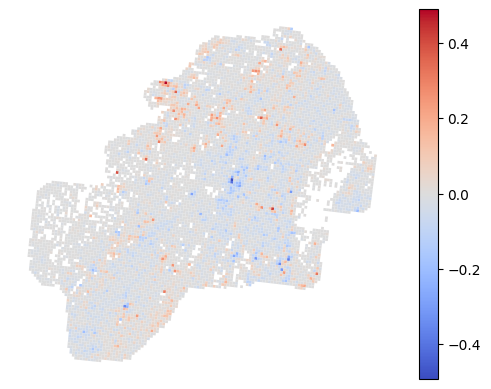

In [101]:
fig,ax = plt.subplots()

df[ df['Developped-No Change-perc'] != 1 ].plot( ax=ax , cmap = "coolwarm", column="NTA-Sum-perc" , legend=True )
ax.axis('off')

In [97]:
df.to_file(r"C:\Users\cansu\Dropbox\studio2263\Thrive\GIS\landuse\landuse_Change_1miGrid_Calc.geojson", driver="GeoJSON" )